Pregunta: ¿Qué tipo de problemas se pueden resolver con regresión lineal?
RTA:La regresión lineal se usa para resolver problemas donde queremos predecir un valor numérico a partir de una o varias variables. Por ejemplo, estimar el precio de una casa según su tamaño, prever las ventas de un producto según la publicidad o calcular la temperatura en función del tiempo. En general, se aplica cuando existe una relación lineal entre las variables.

In [ ]:
#Importa el/los módulo(s) pandas as pd para usarlos en el análisis.
import pandas as pd
# Lee un archivo CSV y lo carga en un DataFrame de Pandas.
bike_data = pd.read_csv("daily-bike-share.csv")

In [ ]:
# Paso 1: Importar librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# Muestra las primeras 5 filas del dataset
bike_data.head(5)
# Muestra información general del dataset
bike_data.info()
# Genera una tabla con la descripción de cada campo y su significado
bike_data.describe()
# predecir variable rentals


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  rentals     731 non-null    int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 80.1+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000


In [ ]:

# Extrae el día del mes desde columna fecha
bike_data['dteday'] = pd.to_datetime(bike_data['dteday'])
bike_data['day'] = bike_data['dteday'].dt.day

# Muestra las primeras 25 filas del dataset
bike_data.head(25)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals,day
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,1
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,2
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,3
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,4
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,5
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,6
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,7
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,8
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,9
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,10


In [ ]:
# Definir las características numéricas relevantes del dataset

features = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
            'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

X = bike_data[features]

# Seleccionar la variable objetivo (label)
y = bike_data['rentals']

# Mostrar estadísticas descriptivas de las variables numéricas y el objetivo
print("Estadísticas descriptivas de las variables numéricas:")
display(X.describe())
print("\nEstadísticas descriptivas de la variable objetivo:")
display(y.describe())


Estadísticas descriptivas de las variables numéricas:


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463



Estadísticas descriptivas de la variable objetivo:


,rentals
count,731.000000
mean,848.176471
std,686.622488
min,2.000000
25%,315.500000
50%,713.000000
75%,1096.000000
max,3410.000000


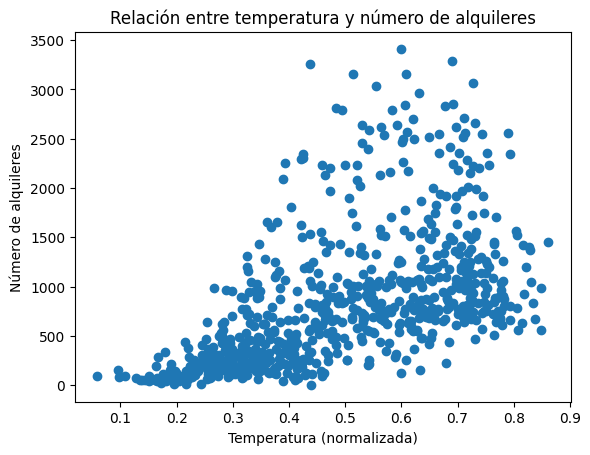

In [ ]:
# TODO: Grafica una dispersión de temperatura vs rentals

plt.scatter(bike_data['temp'], bike_data['rentals'])
plt.xlabel('Temperatura (normalizada)')
plt.ylabel('Número de alquileres')
plt.title('Relación entre temperatura y número de alquileres')
plt.show()
# A mayor temperatura, hay más alquileres de bicicletas y en temperaturas más bajas (0.1–0.3), los alquileres son escasos.

In [ ]:
from sklearn.model_selection import train_test_split

# Definir las características y la variable objetivo
X = bike_data[['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
               'weathersit', 'temp', 'atemp', 'hum', 'windspeed']]
y = bike_data['rentals']  # variable objetivo

# Divide los datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Mostrar cuántas filas tiene cada conjunto
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} filas")

# si usamos un test_size demasiado pequeño puede dar una medida de rendimiento inestable o engañosa, y es posible que el conjunto de prueba no refleje bien la variedad del dataset completo.


Tamaño del conjunto de entrenamiento: 511 filas
Tamaño del conjunto de prueba: 220 filas


In [ ]:
from sklearn.linear_model import LinearRegression

# TODO: Crea y entrena el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Muestra los coeficientes βn
print("Coeficientes (βn):", model.coef_)
print("Intercepto (β0):", model.intercept_)

# rentals = β0 + β1·temp + β2·atemp + β3·hum + β4·windspeed + ...

# Muestra información del modelo entrenado
print("\nModelo entrenado con las siguientes características:")
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.2f}")
# el coeficiente asociado a la temperatura indica cuánto varía el número de alquileres de bicicletas cuando la temperatura aumenta, manteniendo constantes las demás variables.
#En este caso, un valor positivo significa que a medida que la temperatura sube, también aumenta la cantidad de alquileres,
#lo que refleja que el clima cálido incentiva más el uso de bicicletas

Coeficientes (βn): [   72.35624942   245.969367     -16.15064841  -299.30118548
    13.25361978  -840.70542698   -76.66545561  1845.01042853
   103.82488943  -352.70609135 -1053.50245463]
Intercepto (β0): 763.2467693715112

Modelo entrenado con las siguientes características:
season: 72.36
yr: 245.97
mnth: -16.15
holiday: -299.30
weekday: 13.25
workingday: -840.71
weathersit: -76.67
temp: 1845.01
atemp: 103.82
hum: -352.71
windspeed: -1053.50


MSE: 168177.78386090606
RMSE: 410.09484739619205


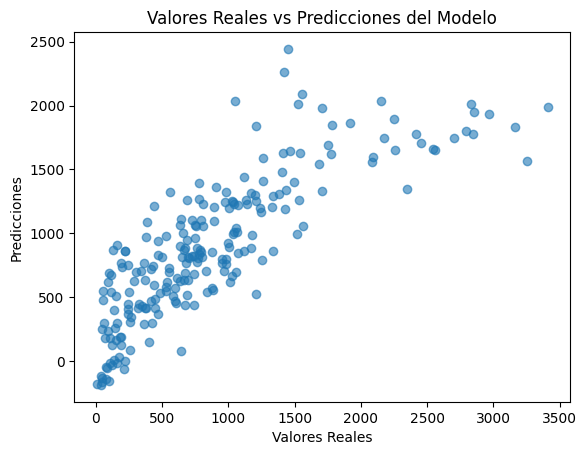

In [ ]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Genera predicciones
y_pred = model.predict(X_test)

# Calcula métrica MSE
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# También puedes calcular el RMSE (raíz cuadrada del MSE)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# Grafica valores reales vs predichos
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones del Modelo")
plt.show()

#El MSE indica qué tan grandes son los errores en promedio (cuanto más pequeño, mejor)
#El RMSE muestra ese error en las mismas unidades de la variable real, ayudándonos a entender más fácilmente qué tan cerca están las predicciones de los valores reales


In [ ]:
# Seleccionamos solo la columna 'temp' como característica
X_temp = bike_data[['temp']]
y = bike_data['rentals']

# División en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_temp, y, test_size=0.3, random_state=0)

# Entrenamos el modelo
model_temp = LinearRegression()
model_temp.fit(X_train, y_train)

# Predicciones
y_pred_temp = model_temp.predict(X_test)

# Calculamos el MSE y RMSE
mse_temp = mean_squared_error(y_test, y_pred_temp)
rmse_temp = np.sqrt(mse_temp)

print("MSE (solo temp):", mse_temp)
print("RMSE (solo temp):", rmse_temp)

#El modelo multivariable es más preciso porque considera varios factores que influyen en los alquileres de bicicletas, no solo la temperatura.
#Al incluir variables como la humedad, el viento o la sensación térmica, logra una visión más completa del comportamiento real de los usuarios y reduce el error de predicción.
#En cambio, el modelo con solo la temperatura es más simple y pierde información importante.

MSE (solo temp): 374482.8022842907
RMSE (solo temp): 611.9499998237525
